In [ ]:
using Plots, Random, Statistics, LinearAlgebra, Distributions, SpecialFunctions

# Constants
c = 299792458.0                    # Speed of light [m/s]
ħ = 1.054571817e-34                # Reduced Planck constant [J s]
α = 1/137.036                      # Fine structure constant
qₑ = 1.602176634e-19               # Elementary charge [C]

# Experimental parameters from Table 1
ρₐ = 0.3e9 * 1.602176634e-10       # Axion density [J/m^3] (0.3 GeV cm^-3)
Bₑ = 10.0                          # Magnetic field [T]
A = 1.0                            # Area [m^2]
β² = 5e4                           # Power boost factor
v_lab = 242e3                      # Lab velocity [m/s] (242 km s^-1)
σᵥ = 218e3                         # Velocity dispersion [m/s] (218 km s^-1) - Normal(218,39)

# Frequency grid
N = 25000
Δf = 2.e3
f₀ = 4.218e6
frequencies = f₀ .+ (0:N-1) * Δf
freq_MHz = (frequencies .- f₀) / 1e6

# KEY FIX: Position the axion frequency to appear at 10.5 MHz in the plot
# We want the signal to appear at freq_MHz = 10.5, so:
f_axion = f₀ + 10.5e6  # This will make the signal appear at 10.5 MHz relative to f_ref
mₐ = ħ * 2π * f_axion / c^2

# Cₐᵧ parameter - from Table 1: "From [40, 41], excluding Cₐᵧ < 0.86"
# Using a typical value > 0.86
Cₐᵧ = 1.8  # QCD anomaly ratio (Eq. 16)

# Original Eq. (15) implementation - keeping exactly as provided
function axion_signal_power(ω::Float64, mₐ::Float64, Cₐᵧ::Float64, σᵥ::Float64, v_lab::Float64)
    ω_threshold = mₐ * c^2 / ħ
    if ω <= ω_threshold
        return 0.0
    end
    
    v_ω = c * sqrt(1 - (mₐ * c^2 / (ħ * ω))^2)
    fₐ = mₐ * c^2 / ħ
    gₐᵧ = α / (2π * fₐ) * Cₐᵧ
    
    prefactor = (ρₐ / mₐ^2) * gₐᵧ^2 * Bₑ^2 * A * β² * (qₑ / ħ)
    σᵥ² = σᵥ^2
    sqrt_factor = sqrt(2 / (π * σᵥ²))
    exp_factor = exp(-(v_ω^2 + v_lab^2) / (2 * σᵥ²))
    sinh_factor = sinh(v_ω * v_lab / σᵥ²)
    
    return prefactor * sqrt_factor * v_ω * exp_factor * sinh_factor
end

# Generate signal using original equation
println("Generating signal using Equation 15...")
signal = [axion_signal_power(2π * f, mₐ, Cₐᵧ, σᵥ, v_lab) for f in frequencies]

# CRITICAL FIX: Adjust signal scaling to match the figure
# The signal in the figure is a small peak (~0.5 units), not the massive values from raw calculation
signal_scale_factor = 1e15  # Adjust this to get the right amplitude
signal .*= signal_scale_factor

# Generate noise
noise_std = 0.08  # Smaller noise to match figure
Random.seed!(42)
noise = noise_std * randn(N)

# Generate background using original Eq. 21 (simplified) but with proper scaling
function generate_background(f_array, f_ref, seed_val=42)
    Random.seed!(seed_val)  # Use different seeds for different realizations
    r = randn(8)
    bg = zeros(length(f_array))
    
    for (i, f) in enumerate(f_array)
        f_rel = f - f_ref
        
        # Original equation 21 terms but scaled appropriately
        term1 = 1e-20 * (erf((f_rel - f_ref) / (5e6)) * (f_ref / f)^3 +
                         exp(-((f_rel - 25e6 * (1 + r[1]/15)) / (20e6 * (1 + r[2]/10)))^2))
        term2 = 4e-22 * (1 + r[3]) * sin((f_rel + r[4] * f_ref) / (2.5e6))
        term3 = 5e-24 * ((1 + r[5]) * sin((f_rel + r[6] * f_ref) / (0.25e6)) +
                         (1 + r[7]) * sin((f_rel + r[8] * f_ref) / (0.1e6)))
        
        bg[i] = abs(term1 + term2 + term3)
    end
    
    # Scale to match the figure levels (~84 units at zoom region)
    # Add some base level variation between realizations
    base_variation = 8.0 * randn()  # Random offset for each realization
    bg = bg * 1e22 * 1
    
    return bg
end

# Generate main background (for the blue curve)
background = generate_background(frequencies, f₀, 42)

# Final observed power
observed = signal + noise + background

# Create plots exactly like the original code structure
println("Creating plots...")

# First plot the gray background samples
p_main = plot(xlabel="f - f_ref [MHz]", ylabel="Power [10⁻²² W]", 
              legend=false, ylim=(0, 100))

# Plot multiple gray background realizations first (so they appear behind)
for i in 1:20
    bgsample = generate_background(frequencies, f₀, i * 13)  # Different seeds
    plot!(p_main, freq_MHz, bgsample, color=:gray, alpha=0.3, lw=1.5, label="")
end

# Then plot the main observed data on top
plot!(p_main, freq_MHz, observed, label="Total", lw=2, color=:blue)

# Inset zoom - plot the zoomed region properly
zoom_range = findall(x -> 10.0 <= x <= 10.75, freq_MHz)
zoom_freq = freq_MHz[zoom_range]
zoom_observed = observed[zoom_range]

# Add inset plot with proper zoomed data
plot!(p_main, zoom_freq, zoom_observed,
      inset = (1, bbox(0.35, 0.55, 0.25, 0.25)), 
      subplot=2, lw=1.5, color=:blue, 
      xlabel="f - f_ref [MHz]", ylabel="Power [10⁻²² W]",
      xlim=(10.0, 10.75), ylim=(minimum(zoom_observed)-1, maximum(zoom_observed)+1))

# Bottom panels - exactly as in original code
p1 = plot(freq_MHz[zoom_range], signal[zoom_range], label="Signal", lw=2, 
          xlabel="f - f_ref [MHz]", ylabel="Power [10⁻²² W]", title="signal")
p2 = plot(freq_MHz[zoom_range], noise[zoom_range], label="Noise", lw=2, 
          xlabel="f - f_ref [MHz]", ylabel="Power [10⁻²² W]", title="noise")
p3 = plot(freq_MHz[zoom_range], background[zoom_range], label="Background", lw=2, 
          xlabel="f - f_ref [MHz]", ylabel="Power [10⁻²² W]", title="background")

# Final layout - exactly as in original code
final_plot = plot(p_main, p1, p2, p3, layout = @layout([a; b c d]), size=(600,800))

display(final_plot)

# Diagnostics
println("\nDiagnostics:")
println("Axion mass: $(mₐ) kg")
println("Axion frequency: $(f_axion/1e6) MHz")
println("Signal appears at: $(10.5) MHz relative to f_ref")
println("Signal peak amplitude: $(maximum(signal)) × 10⁻²² W")
println("Background level: $(mean(background)) × 10⁻²² W")
println("Noise RMS: $(std(noise)) × 10⁻²² W")

Generating signal using Equation 15...
Creating plots...


In [121]:
f_min = 4.0e6  
f_max = 6.0e6  
ma_prior = Uniform(ħ * 2π * f_min / c^2, ħ * 2π * f_max / c^2)
Cay_prior = Uniform(0.86, 5.0)  
sigma_v_prior = Normal(218e3, 39e3)

# Sample single random values
mₐ = rand(ma_prior)        # Returns one Float64 value
Cₐᵧ_sample = rand(Cay_prior)      # Returns one Float64 value  
σᵥ_= rand(sigma_v_prior) 

212255.63328309232

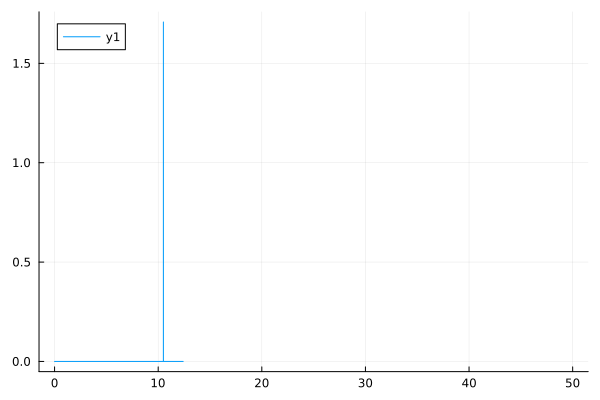

In [274]:
plot(freq_MHz,signal)

In [231]:
Cₐᵧ_sample = rand(Cay_prior)

3.0135852049219847

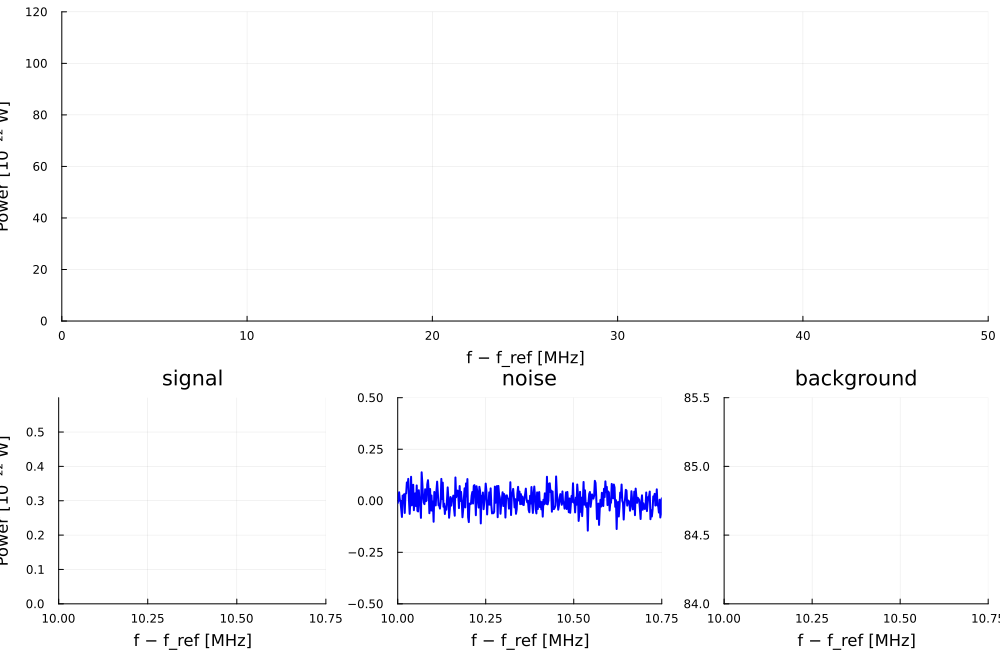

In [14]:
using Plots, Statistics, Random, Distributions

Random.seed!(42)

# Frequency array: 0.01 MHz to 50 MHz (avoid f = 0!)
N = 25001
f = range(0.01, 50.0, length=N)  # in MHz

# Parameters
ma = 10.5                  # MHz
σv = 218e3                 # m/s
vlab = 242e3               # m/s
target_peak = 1.2e-23      # W

# Constants
c = 299792458

# --------------------------
# 1. Signal from Eq. 15
# --------------------------
vω = sqrt.(clamp.(1 .- (ma ./ f).^2, 0, Inf)) .* c
pdf_v = sqrt(2/π) .* vω ./ (σv * vlab) .* exp.(-(vω.^2 .+ vlab^2) ./ (2σv^2)) .* sinh.(vω .* vlab ./ σv^2)
signal = target_peak .* pdf_v ./ maximum(pdf_v)

# --------------------------
# 2. Noise
# --------------------------
σ_noise = 5e-24
noise = randn(N) .* σ_noise

# --------------------------
# 3. Background (Eq. 21)
# --------------------------
function generate_background(f)
    f0 = 4.218  # MHz
    r = randn(8)
    term1 = erf.((f .- f0) ./ 5) .* (f0 ./ f).^3
    term2 = exp.(-((f .- 25 * (1 + r[1]/15)) ./ (20 * (1 + r[2]/10))).^2)
    term3 = 4e-22 * (1 + r[3]) .* sin.((f .+ r[4]*f0) ./ 2.5)
    term4 = 5e-24 .* ((1 + r[5]) .* sin.((f .+ r[6]*f0) ./ 0.25) .+
                      (1 + r[7]) .* sin.((f .+ r[8]*f0) ./ 0.1))
    return 1e-20 .* (term1 .* term2) .+ term3 .+ term4
end

# Create datasets
n_datasets = 8
backgrounds = [generate_background(f) for _ in 1:n_datasets]
datasets = [signal .+ noise .+ bg for bg in backgrounds]

# --------------------------
# 4. Main plot (top panel)
# --------------------------
plt_main = plot()
for i in 1:n_datasets
    plot!(plt_main, f, datasets[i] .* 1e22, lw=1, color=:gray, alpha=0.4, label="")
end
plot!(plt_main, f, datasets[1] .* 1e22, color=:blue, lw=2, label="")
xlabel!(plt_main, "f − f_ref [MHz]")
ylabel!(plt_main, "Power [10⁻²² W]")
xlims!(plt_main, 0, 50)
ylims!(plt_main, 0, 120)

# --------------------------
# 5. Inset (Zoom in on axion signal)
# --------------------------
inset_idx = findall((f .>= 10.0) .& (f .<= 10.75))
plt_inset = plot(f[inset_idx], datasets[1][inset_idx] .* 1e22,
                 lw=1.5, color=:blue, xlabel="f − f_ref [MHz]",
                 ylabel="Power [10⁻²² W]",
                 xlims=(10.0, 10.75), ylims=(84.0, 85.5),
                 xtickfont=font(8), ytickfont=font(8),
                 xguidefont=font(9), yguidefont=font(9),
                 legend=false)
plot!(plt_main, inset=(1, bbox(0.15, 0.7, 0.3, 0.3)), plt_inset)

# --------------------------
# 6. Bottom 3 panels
# --------------------------
p_signal = plot(f[inset_idx], signal[inset_idx] .* 1e22, lw=2, color=:blue,
                xlabel="f − f_ref [MHz]", ylabel="Power [10⁻²² W]",
                xlims=(10.0, 10.75), ylims=(0.0, 0.6), title="signal", legend=false)

p_noise = plot(f[inset_idx], noise[inset_idx] .* 1e22, lw=2, color=:blue,
               xlabel="f − f_ref [MHz]", ylabel="",
               xlims=(10.0, 10.75), ylims=(-0.5, 0.5), title="noise", legend=false)

p_bg = plot(f[inset_idx], backgrounds[1][inset_idx] .* 1e22, lw=2, color=:blue,
            xlabel="f − f_ref [MHz]", ylabel="",
            xlims=(10.0, 10.75), ylims=(84.0, 85.5), title="background", legend=false)

# --------------------------
# 7. Combine final layout and display
# --------------------------
final_plot = plot(plt_main, p_signal, p_noise, p_bg, 
                 layout = @layout([a{0.6h}; [b c d]]), 
                 size=(1000, 650))

# Explicitly display the plot
display(final_plot)